XBOOST

c:\Users\esram\OneDrive\Desktop\esrabecode\immo-eliza-ml\scripts\clean_data.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  has_whitespace = df.applymap(lambda x: isinstance(x, str) and x != x.strip()).any().any()


Contains whitespace? False
Not matched types: ['apartment' 'land' 'undetermined-property' 'other']


c:\Users\esram\OneDrive\Desktop\esrabecode\immo-eliza-ml\scripts\model_xgboost.py:106: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(group_copy[outlier_num_cols], nan_policy='omit'))
c:\Users\esram\OneDrive\Desktop\esrabecode\immo-eliza-ml\scripts\model_xgboost.py:106: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(group_copy[outlier_num_cols], nan_policy='omit'))


Train → RMSE: 71516.59, MAE: 46426.14, R²: 0.9269
Validation → RMSE: 164408.57, MAE: 76932.63, R²: 0.6670
Test → RMSE: 235081.00, MAE: 80607.30, R²: 0.6478


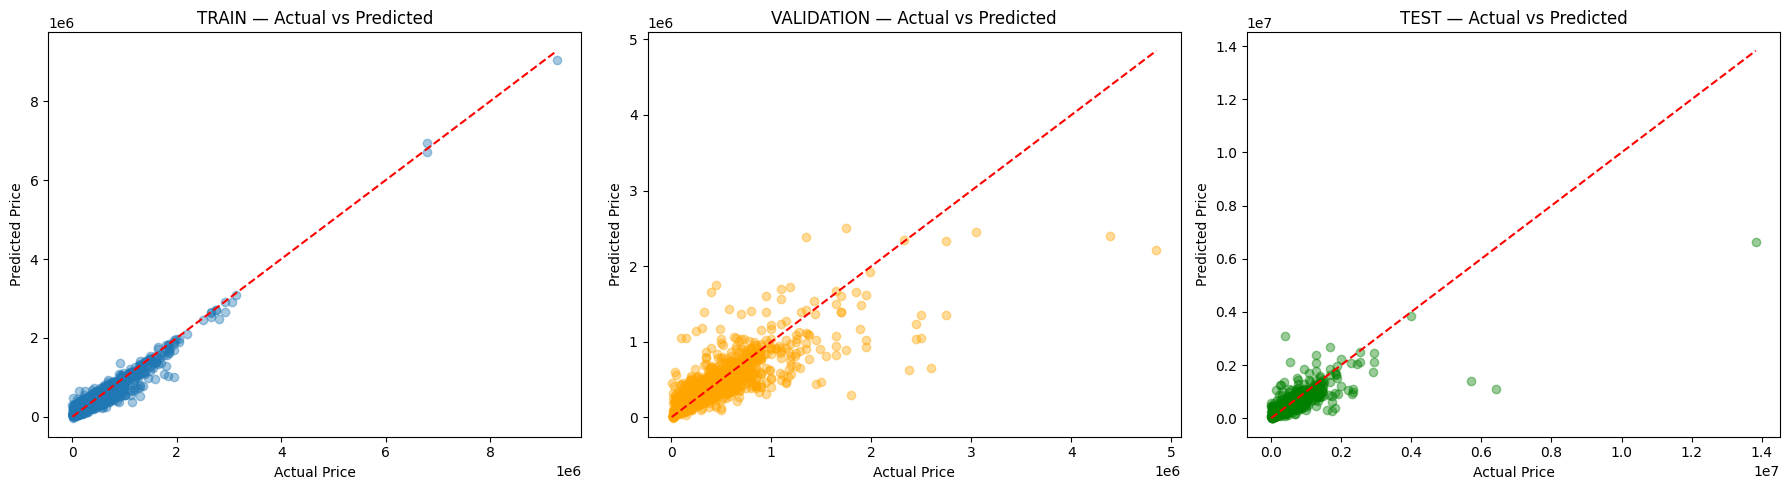

In [ ]:
import sys
import os
import pandas as pd
import numpy as np

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from scripts.clean_data import clean_immo_data
from scripts.model_xgboost import run_xgb_pipeline_basic, plot_xgb_pipeline_results

# Veri yükle ve temizle
file_path = os.path.join(repo_root, "data", "immovlan_cleaned_file_final.csv")
df = clean_immo_data(file_path)

# XGBoost pipeline çalıştır
model_xgb, X_tr_xgb, X_val_xgb, X_test_xgb, y_tr_xgb, y_val_xgb, y_test_xgb = \
    run_xgb_pipeline_basic(df.copy())

# Sonuçları plotla
plot_xgb_pipeline_results(
    model_xgb,
    X_tr_xgb, X_val_xgb, X_test_xgb,
    y_tr_xgb, y_val_xgb, y_test_xgb
)
